
# Report-quality analysis: 3D Heisenberg + DMI Monte Carlo

This notebook reads the C++ simulation output from

```text
results/processed/summary.csv
results/processed/summary_by_L_T_mean.csv
results/processed/summary_by_L_T_std.csv
```

and produces report-ready figures for:

- energy density $\langle E\rangle/N$,
- magnetization density $\langle |M|\rangle/N$,
- magnetic susceptibilities,
- heat capacity $C_V/N$,
- helical order parameter $\max_{q\neq 0} S(q)$,
- helical susceptibility-like fluctuations,
- theoretical checks for the helix pitch and low-temperature energy.

The output figures are written to:

```text
figures/report/
```

Run this notebook from either the project root or from the `notebooks/` folder.


In [19]:

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Basic, report-friendly matplotlib settings.
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.figsize": (6.2, 4.2),
    "figure.dpi": 120,
    "savefig.bbox": "tight",
})


def find_project_root() -> Path:
    """Find the termproject root folder from the current notebook location."""
    cwd = Path.cwd().resolve()
    candidates = [cwd] + list(cwd.parents)
    for p in candidates:
        if (p / "results").exists() and (p / "src").exists():
            return p
    # Fallback: if launched from notebooks, use parent; otherwise current directory.
    if cwd.name == "notebooks":
        return cwd.parent
    return cwd


ROOT = find_project_root()
PROCESSED = ROOT / "results" / "processed"
CONFIGS = ROOT / "results" / "configs"
FIG_DIR = ROOT / "figures" / "report"
TABLE_DIR = ROOT / "results" / "processed" / "report_tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Processed results:", PROCESSED)
print("Figures will be written to:", FIG_DIR)


Project root: /home/iason/projects/CSP26/Computational_Statistical_Physics/Project
Processed results: /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/results/processed
Figures will be written to: /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report



## Load simulation data

`summary.csv` contains one row per independent run, typically one row per `(L, T, seed)`.
The seed-averaged files are useful, but this notebook mostly recomputes means and standard errors directly from `summary.csv`, so that the error bars are consistent.


In [20]:

summary_path = PROCESSED / "summary.csv"
if not summary_path.exists():
    raise FileNotFoundError(
        f"Could not find {summary_path}. Run first:\n"
        "  python3 scripts/collect_results.py"
    )

raw = pd.read_csv(summary_path)
raw = raw.sort_values(["L", "T", "seed"]).reset_index(drop=True)

print(f"Loaded {len(raw)} runs")
print("Columns:")
print(list(raw.columns))
raw.head()


Loaded 285 runs
Columns:
['L', 'T', 'J', 'D', 'Bx', 'By', 'Bz', 'seed', 'therm_sweeps', 'samples', 'skip', 'proposal_width', 'E_density_mean', 'E_density_stderr', 'M_abs_mean', 'M_abs_stderr', 'chi_abs', 'chi_vec', 'Cv_per_spin', 'helical_order_mean', 'helical_order_stderr', 'helical_susc_like', 'acceptance_rate', 'q_peak_final', 'axis_peak_final', 'n_peak_final', 'ml_configs_saved']


,L,T,J,D,Bx,By,Bz,seed,therm_sweeps,samples,...,chi_vec,Cv_per_spin,helical_order_mean,helical_order_stderr,helical_susc_like,acceptance_rate,q_peak_final,axis_peak_final,n_peak_final,ml_configs_saved
0,8,0.8,1,1,0,0,0,1,2000,3000,...,2.307564,1.296228,0.253938,0.000622,0.743141,0.733982,0.785398,2,1,0
1,8,0.8,1,1,0,0,0,2,2000,3000,...,2.220860,1.330208,0.258811,0.000656,0.825622,0.734124,5.497787,2,7,0
2,8,0.8,1,1,0,0,0,3,2000,3000,...,2.290203,1.203138,0.261540,0.000539,0.557017,0.733741,5.497787,2,7,0
3,8,0.8,1,1,0,0,0,4,2000,3000,...,2.410424,1.277954,0.263400,0.000526,0.531058,0.733687,5.497787,2,7,0
4,8,0.8,1,1,0,0,0,5,2000,3000,...,2.284270,1.274323,0.254051,0.000643,0.792835,0.734320,5.497787,2,7,0


In [21]:

# Columns used throughout the analysis.
GROUP_COLS = ["L", "T", "J", "D", "Bx", "By", "Bz"]

# Some simulations might not have all optional columns, so we guard accesses below.
def require_columns(df: pd.DataFrame, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

require_columns(raw, ["L", "T", "J", "D", "seed", "E_density_mean", "M_abs_mean", "Cv_per_spin", "helical_order_mean"])

# Number of seeds per L,T.
seed_counts = raw.groupby(["L", "T"], as_index=False)["seed"].nunique().rename(columns={"seed": "n_seeds"})
seed_counts.head()


,L,T,n_seeds
0,8,0.80,5
1,8,0.90,5
2,8,1.00,5
3,8,1.10,5
4,8,1.15,5



## Helper functions

Error bars are computed as the standard error over independent seeds whenever there is more than one seed. If only one seed is available, the notebook omits the seed error bar for observables without a separate within-chain error estimate.


In [22]:

def grouped_stats(df: pd.DataFrame, y_col: str) -> pd.DataFrame:
    """Mean and standard error over seeds for a chosen observable."""
    require_columns(df, GROUP_COLS + ["seed", y_col])
    g = (
        df.groupby(GROUP_COLS, as_index=False)
        .agg(
            y_mean=(y_col, "mean"),
            y_std=(y_col, "std"),
            n_seeds=("seed", "nunique"),
        )
        .sort_values(["L", "T"])
        .reset_index(drop=True)
    )
    g["y_sem"] = g["y_std"] / np.sqrt(g["n_seeds"])
    return g


def save_figure(fig, filename_base: str):
    """Save both PDF and PNG versions."""
    pdf = FIG_DIR / f"{filename_base}.pdf"
    png = FIG_DIR / f"{filename_base}.png"
    fig.savefig(pdf)
    fig.savefig(png, dpi=250)
    print(f"Saved {pdf}")
    print(f"Saved {png}")


def plot_observable(
    df: pd.DataFrame,
    y_col: str,
    ylabel: str,
    filename_base: str,
    title: str | None = None,
    show_errorbars: bool = True,
    marker: str = "o",
):
    """Plot one observable versus temperature for all available system sizes."""
    stats = grouped_stats(df, y_col)
    fig, ax = plt.subplots()

    for L, g in stats.groupby("L"):
        g = g.sort_values("T")
        yerr = None
        if show_errorbars and g["n_seeds"].max() > 1:
            yerr = g["y_sem"].to_numpy()
        ax.errorbar(
            g["T"],
            g["y_mean"],
            yerr=yerr,
            marker=marker,
            capsize=3 if yerr is not None else 0,
            linewidth=1.6,
            label=fr"$L={int(L)}$",
        )

    ax.set_xlabel(r"Temperature $T$")
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.legend(frameon=False)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    save_figure(fig, filename_base)
    return fig, ax, stats


def peak_estimates(df: pd.DataFrame, y_col: str, name: str) -> pd.DataFrame:
    """Estimate pseudo-critical temperatures from the maximum of a response function."""
    stats = grouped_stats(df, y_col)
    rows = []
    for L, g in stats.groupby("L"):
        g = g.sort_values("T")
        idx = g["y_mean"].idxmax()
        row = g.loc[idx]
        rows.append({
            "observable": name,
            "L": int(L),
            "T_peak": float(row["T"]),
            "peak_value": float(row["y_mean"]),
            "n_seeds": int(row["n_seeds"]),
        })
    return pd.DataFrame(rows)


def steepest_drop_estimates(df: pd.DataFrame, y_col: str = "helical_order_mean") -> pd.DataFrame:
    """Estimate transition region from the steepest drop of the helical order parameter."""
    stats = grouped_stats(df, y_col)
    rows = []
    for L, g in stats.groupby("L"):
        g = g.sort_values("T")
        if len(g) < 3:
            continue
        T = g["T"].to_numpy(dtype=float)
        y = g["y_mean"].to_numpy(dtype=float)
        grad = np.gradient(y, T)
        idx = int(np.argmin(grad))
        rows.append({
            "observable": "steepest drop of helical order",
            "L": int(L),
            "T_drop": float(T[idx]),
            "slope": float(grad[idx]),
            "helical_order_at_drop": float(y[idx]),
            "n_seeds": int(g["n_seeds"].iloc[idx]),
        })
    return pd.DataFrame(rows)



## Main observables

These are the direct analogues of the Exercise 01 plots, with the additional helical order parameter suitable for the DMI system.


Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/energy_density_vs_T_report.pdf
Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/energy_density_vs_T_report.png


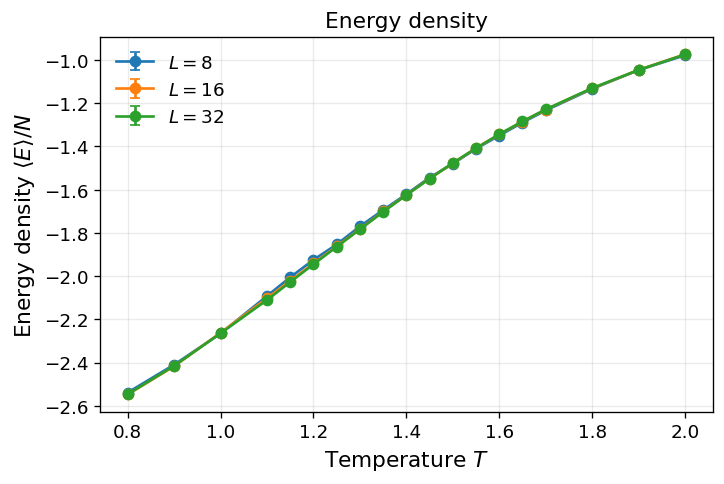

In [23]:

fig_energy, ax_energy, energy_stats = plot_observable(
    raw,
    "E_density_mean",
    ylabel=r"Energy density $\langle E\rangle/N$",
    filename_base="energy_density_vs_T_report",
    title="Energy density",
)


Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/magnetization_density_vs_T_report.pdf
Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/magnetization_density_vs_T_report.png


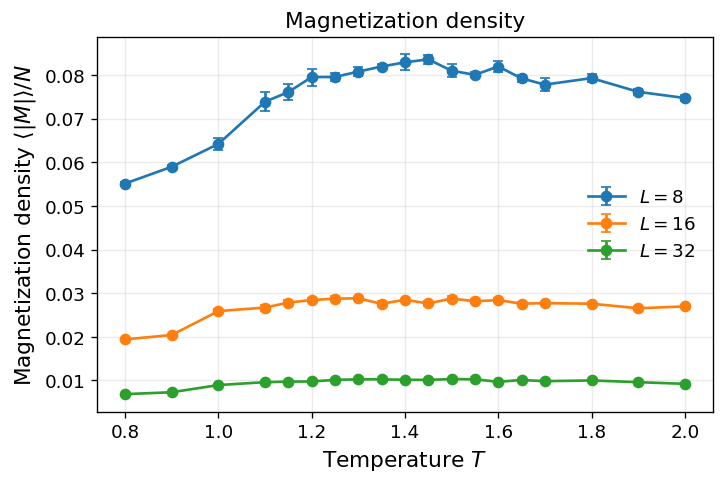

In [24]:

fig_mag, ax_mag, mag_stats = plot_observable(
    raw,
    "M_abs_mean",
    ylabel=r"Magnetization density $\langle |M|\rangle/N$",
    filename_base="magnetization_density_vs_T_report",
    title="Magnetization density",
)


Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/heat_capacity_vs_T_report.pdf
Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/heat_capacity_vs_T_report.png


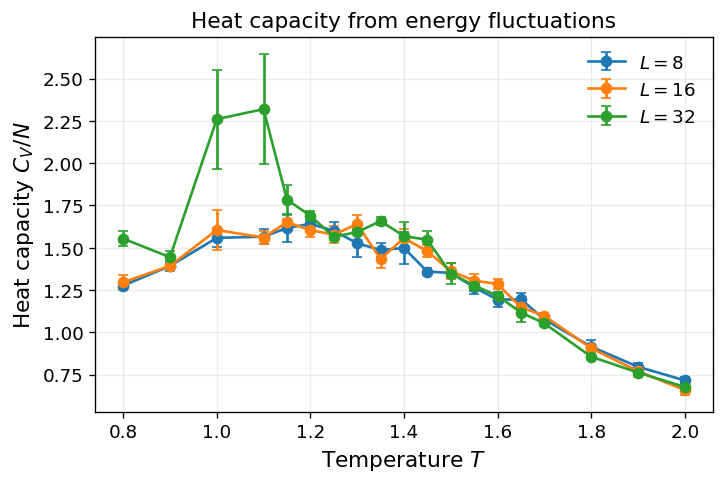

In [25]:

fig_cv, ax_cv, cv_stats = plot_observable(
    raw,
    "Cv_per_spin",
    ylabel=r"Heat capacity $C_V/N$",
    filename_base="heat_capacity_vs_T_report",
    title="Heat capacity from energy fluctuations",
)


Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/helical_order_vs_T_report.pdf
Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/helical_order_vs_T_report.png


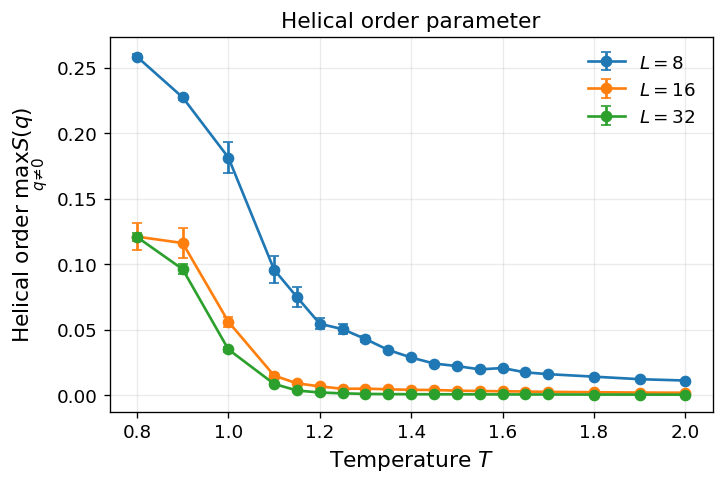

In [26]:

fig_h, ax_h, helical_stats = plot_observable(
    raw,
    "helical_order_mean",
    ylabel=r"Helical order $\max_{q\neq 0} S(q)$",
    filename_base="helical_order_vs_T_report",
    title="Helical order parameter",
)


Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/susceptibility_abs_vs_T_report.pdf
Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/susceptibility_abs_vs_T_report.png
Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/susceptibility_vec_vs_T_report.pdf
Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/susceptibility_vec_vs_T_report.png


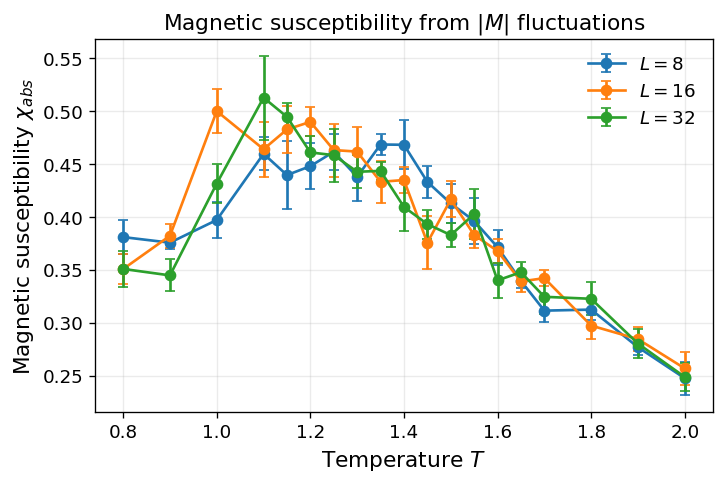

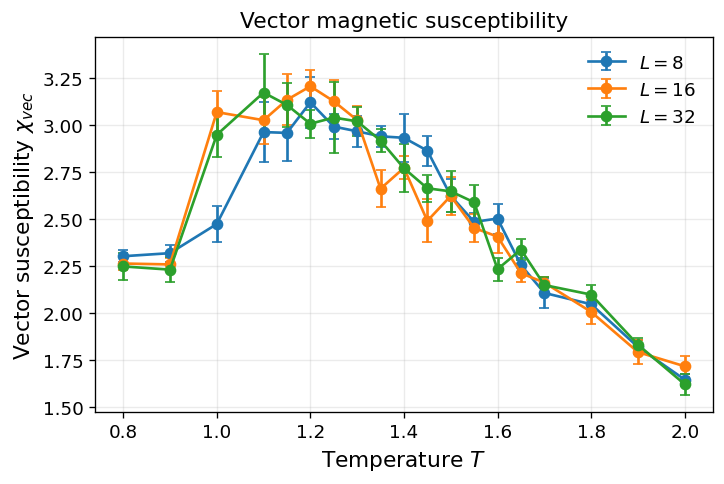

In [27]:

if "chi_abs" in raw.columns:
    fig_chi_abs, ax_chi_abs, chi_abs_stats = plot_observable(
        raw,
        "chi_abs",
        ylabel=r"Magnetic susceptibility $\chi_{abs}$",
        filename_base="susceptibility_abs_vs_T_report",
        title="Magnetic susceptibility from $|M|$ fluctuations",
    )

if "chi_vec" in raw.columns:
    fig_chi_vec, ax_chi_vec, chi_vec_stats = plot_observable(
        raw,
        "chi_vec",
        ylabel=r"Vector susceptibility $\chi_{vec}$",
        filename_base="susceptibility_vec_vs_T_report",
        title="Vector magnetic susceptibility",
    )


Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/helical_susc_like_vs_T_report.pdf
Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/helical_susc_like_vs_T_report.png


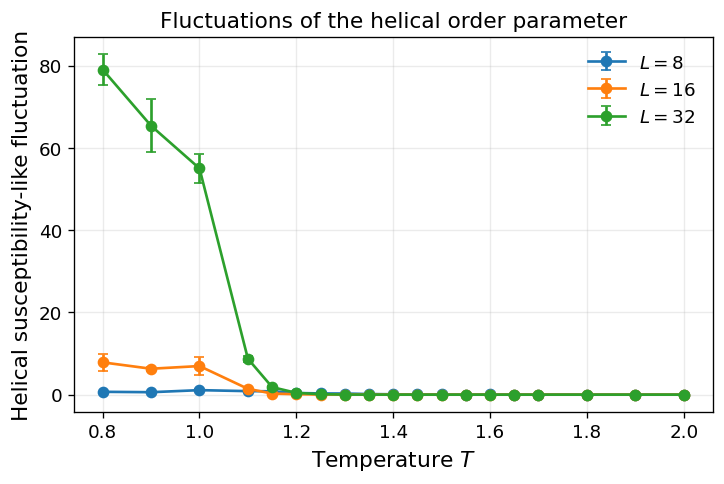

In [28]:

if "helical_susc_like" in raw.columns:
    fig_hs, ax_hs, hs_stats = plot_observable(
        raw,
        "helical_susc_like",
        ylabel=r"Helical susceptibility-like fluctuation",
        filename_base="helical_susc_like_vs_T_report",
        title="Fluctuations of the helical order parameter",
    )



## Pseudo-critical temperature estimates

For finite systems, response peaks are rounded. The peak locations should be interpreted as pseudo-critical temperatures $T_c(L)$, not as the exact thermodynamic-limit critical temperature.


In [29]:

peak_tables = []
peak_tables.append(peak_estimates(raw, "Cv_per_spin", "heat capacity"))
if "chi_abs" in raw.columns:
    peak_tables.append(peak_estimates(raw, "chi_abs", "chi_abs"))
if "chi_vec" in raw.columns:
    peak_tables.append(peak_estimates(raw, "chi_vec", "chi_vec"))
if "helical_susc_like" in raw.columns:
    peak_tables.append(peak_estimates(raw, "helical_susc_like", "helical_susc_like"))

peaks = pd.concat(peak_tables, ignore_index=True)
drops = steepest_drop_estimates(raw, "helical_order_mean")

peaks.to_csv(TABLE_DIR / "pseudo_critical_peak_estimates.csv", index=False)
drops.to_csv(TABLE_DIR / "helical_order_steepest_drop_estimates.csv", index=False)

print("Peak estimates:")
display(peaks)
print("Steepest drop estimates:")
display(drops)


Peak estimates:


,observable,L,T_peak,peak_value,n_seeds
0,heat capacity,8,1.20,1.641110,5
1,heat capacity,16,1.15,1.650872,5
2,heat capacity,32,1.10,2.319578,5
3,chi_abs,8,1.35,0.468202,5
4,chi_abs,16,1.00,0.499729,5
5,chi_abs,32,1.10,0.512465,5
6,chi_vec,8,1.20,3.122361,5
7,chi_vec,16,1.20,3.207503,5
8,chi_vec,32,1.10,3.173981,5
9,helical_susc_like,8,1.00,1.095257,5


Steepest drop estimates:


,observable,L,T_drop,slope,helical_order_at_drop,n_seeds
0,steepest drop of helical order,8,1.0,-0.657730,0.181372,5
1,steepest drop of helical order,16,1.0,-0.506021,0.055936,5
2,steepest drop of helical order,32,1.0,-0.437924,0.034810,5


Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/pseudo_critical_temperature_vs_L_report.pdf
Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/pseudo_critical_temperature_vs_L_report.png


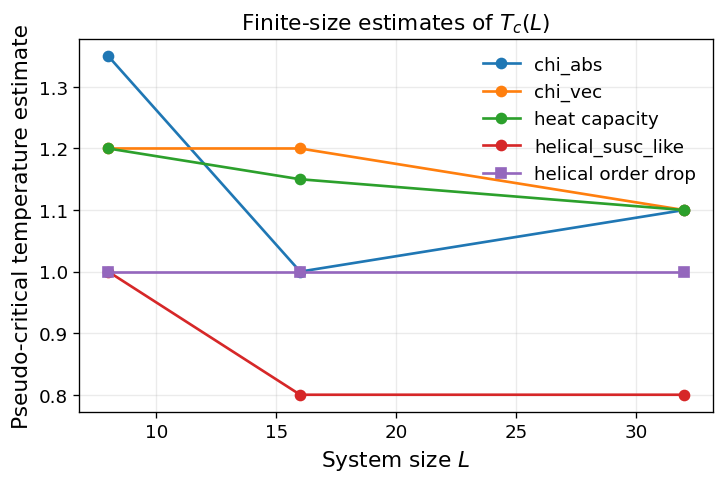

In [30]:

# Plot pseudo-critical estimates versus system size, if several L values are available.
if peaks["L"].nunique() > 1:
    fig, ax = plt.subplots()
    for obs, g in peaks.groupby("observable"):
        ax.plot(g["L"], g["T_peak"], marker="o", linewidth=1.6, label=obs)
    if not drops.empty:
        ax.plot(drops["L"], drops["T_drop"], marker="s", linewidth=1.6, label="helical order drop")
    ax.set_xlabel(r"System size $L$")
    ax.set_ylabel(r"Pseudo-critical temperature estimate")
    ax.set_title(r"Finite-size estimates of $T_c(L)$")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    save_figure(fig, "pseudo_critical_temperature_vs_L_report")
else:
    print("Only one system size available; pseudo-critical vs L plot skipped.")



## Theory checks: helical pitch and low-temperature energy

For a simple helix along one lattice direction, the bond energy along the helix direction is approximately

\[
e(\theta)=-J\cos\theta-D\sin\theta.
\]

Minimization gives

\[
q_0=\theta=\arctan(D/J),
\]

and the corresponding pitch is

\[
\lambda=\frac{2\pi}{q_0}.
\]

For a helix along one axis, a useful ground-state energy estimate is

\[
E_0/N\approx -2J-\sqrt{J^2+D^2}.
\]

The finite lattice only supports momenta $q_n=2\pi n/L$, so the measured peak should be compared with the nearest allowed momentum.


In [31]:

def equivalent_abs_q(q: float) -> float:
    """Map q in [0, 2*pi) to its absolute equivalent in [0, pi]."""
    twopi = 2.0 * math.pi
    q = q % twopi
    return min(q, twopi - q)


def theory_check_table(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (L, J, D), g_all in df.groupby(["L", "J", "D"]):
        L = int(L)
        J = float(J)
        D = float(D)
        q0 = math.atan2(D, J)
        pitch = 2.0 * math.pi / q0 if abs(q0) > 1e-14 else np.inf
        n_nearest = int(round(q0 * L / (2.0 * math.pi)))
        n_nearest = max(1, min(L - 1, n_nearest)) if L > 1 else 0
        q_allowed = 2.0 * math.pi * n_nearest / L if L > 0 else np.nan
        E0_est = -2.0 * J - math.sqrt(J * J + D * D)

        # Use the lowest temperature available for the numerical check.
        T_min = g_all["T"].min()
        g_low = g_all[g_all["T"] == T_min]
        E_low = g_low["E_density_mean"].mean()
        helical_low = g_low["helical_order_mean"].mean()

        q_peak_abs = np.nan
        if "q_peak_final" in g_low.columns:
            q_peak_abs = float(np.nanmean([equivalent_abs_q(q) for q in g_low["q_peak_final"].to_numpy()]))

        rows.append({
            "L": L,
            "J": J,
            "D": D,
            "q0_theory": q0,
            "pitch_theory": pitch,
            "nearest_n": n_nearest,
            "nearest_allowed_abs_q": equivalent_abs_q(q_allowed),
            "measured_abs_q_peak_lowT": q_peak_abs,
            "E0_over_N_estimate": E0_est,
            "T_lowest": float(T_min),
            "E_over_N_lowest_T": float(E_low),
            "helical_order_lowest_T": float(helical_low),
        })
    return pd.DataFrame(rows).sort_values(["L", "J", "D"]).reset_index(drop=True)


theory_checks = theory_check_table(raw)
theory_checks.to_csv(TABLE_DIR / "theory_checks_pitch_energy.csv", index=False)
display(theory_checks)


,L,J,D,q0_theory,pitch_theory,nearest_n,nearest_allowed_abs_q,measured_abs_q_peak_lowT,E0_over_N_estimate,T_lowest,E_over_N_lowest_T,helical_order_lowest_T
0,8,1.0,1.0,0.785398,8.0,1,0.785398,0.785398,-3.414214,0.8,-2.538994,0.258348
1,16,1.0,1.0,0.785398,8.0,2,0.785398,0.785398,-3.414214,0.8,-2.547681,0.120935
2,32,1.0,1.0,0.785398,8.0,4,0.785398,0.785398,-3.414214,0.8,-2.546683,0.120653


Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/dominant_q_vs_T_report.pdf
Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/dominant_q_vs_T_report.png


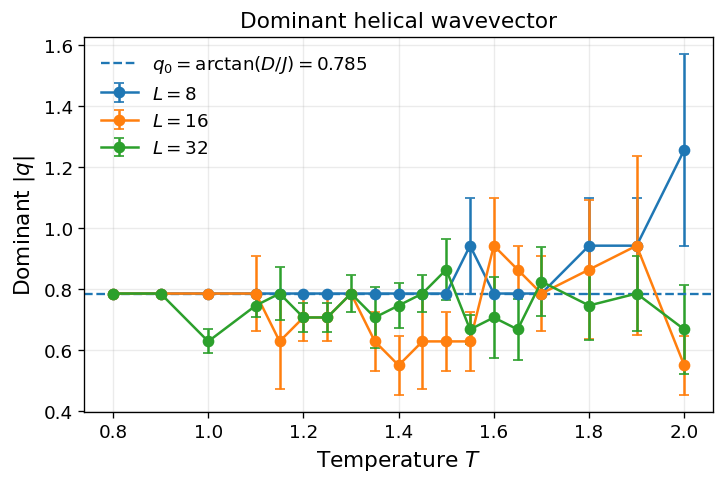

In [32]:

# Plot measured q_peak against the theoretical q0.
if "q_peak_final" in raw.columns:
    fig, ax = plt.subplots()
    for L, g in raw.groupby("L"):
        g = g.copy()
        g["abs_q_peak"] = g["q_peak_final"].apply(equivalent_abs_q)
        q_stats = g.groupby("T", as_index=False).agg(
            q_mean=("abs_q_peak", "mean"),
            q_std=("abs_q_peak", "std"),
            n=("seed", "nunique"),
        )
        q_stats["q_sem"] = q_stats["q_std"] / np.sqrt(q_stats["n"])
        yerr = q_stats["q_sem"].to_numpy() if q_stats["n"].max() > 1 else None
        ax.errorbar(q_stats["T"], q_stats["q_mean"], yerr=yerr, marker="o", capsize=3, label=fr"$L={int(L)}$")

    # Add theoretical q0 line for the first J,D pair.
    J0 = float(raw["J"].iloc[0])
    D0 = float(raw["D"].iloc[0])
    q0 = math.atan2(D0, J0)
    ax.axhline(q0, linestyle="--", linewidth=1.4, label=fr"$q_0=\arctan(D/J)={q0:.3f}$")
    ax.set_xlabel(r"Temperature $T$")
    ax.set_ylabel(r"Dominant $|q|$")
    ax.set_title("Dominant helical wavevector")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    save_figure(fig, "dominant_q_vs_T_report")



## Acceptance rate diagnostic

The proposal width should not be too small. A very high acceptance rate means the spin proposals are conservative; a very low acceptance rate means most proposed moves are rejected. For production, a rough target around $0.4$--$0.7$ is often reasonable, but the optimal value depends on the temperature and observable autocorrelation.


Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/acceptance_rate_vs_T_report.pdf
Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/acceptance_rate_vs_T_report.png


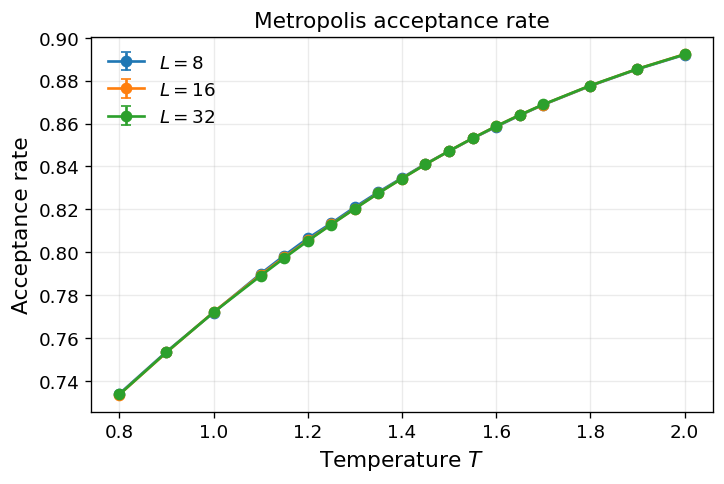

In [33]:

if "acceptance_rate" in raw.columns:
    fig_acc, ax_acc, acc_stats = plot_observable(
        raw,
        "acceptance_rate",
        ylabel="Acceptance rate",
        filename_base="acceptance_rate_vs_T_report",
        title="Metropolis acceptance rate",
    )



## Optional: visualize one saved spin configuration

This works if you ran a simulation with `--save-config`. The C++ code writes files like:

```text
results/configs/config_L16_T0p700_J1p000_D0p700_seed1.csv
```

The plot below shows a single 2D slice of the 3D spin field. The arrows show two selected spin components; the color shows a third component.


Found 1 saved configuration files.
Using: /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/results/configs/config_L8_T0p800_J1p000_D1p000_seed1.csv


Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/spin_slice_example_report.pdf
Saved /home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/spin_slice_example_report.png


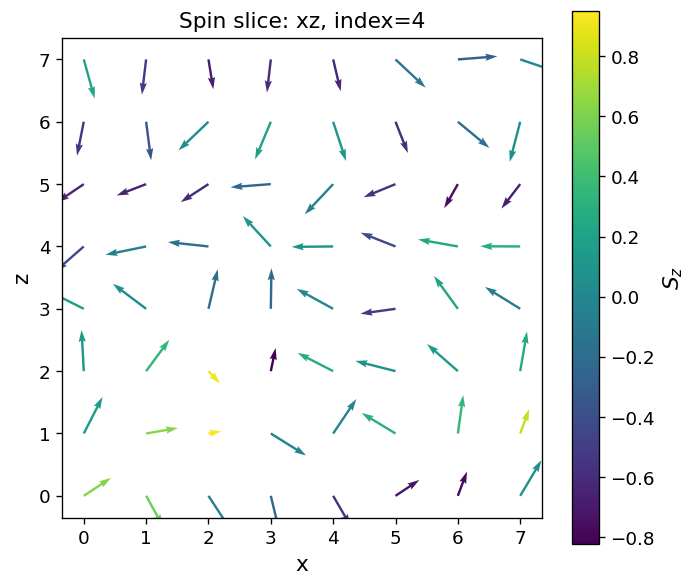

In [34]:

def load_config_csv(path: Path) -> np.ndarray:
    """Load a saved configuration CSV into an array of shape (L,L,L,3)."""
    cfg = pd.read_csv(path)
    require_columns(cfg, ["x", "y", "z", "Sx", "Sy", "Sz"])
    L = int(cfg[["x", "y", "z"]].to_numpy().max()) + 1
    spins = np.zeros((L, L, L, 3), dtype=float)
    for row in cfg.itertuples(index=False):
        spins[int(row.x), int(row.y), int(row.z), :] = [row.Sx, row.Sy, row.Sz]
    return spins


def plot_spin_slice(
    spins: np.ndarray,
    plane: str = "xz",
    index: int | None = None,
    stride: int = 1,
    spin_components: tuple[int, int] = (0, 1),
    color_component: int = 2,
    filename_base: str = "spin_slice_report",
):
    L = spins.shape[0]
    if index is None:
        index = L // 2

    if plane == "xy":
        data = spins[:, :, index, :]
        xlabel, ylabel = "x", "y"
    elif plane == "xz":
        data = spins[:, index, :, :]
        xlabel, ylabel = "x", "z"
    elif plane == "yz":
        data = spins[index, :, :, :]
        xlabel, ylabel = "y", "z"
    else:
        raise ValueError("plane must be one of 'xy', 'xz', 'yz'")

    X, Y = np.meshgrid(np.arange(L), np.arange(L), indexing="ij")
    U = data[:, :, spin_components[0]]
    V = data[:, :, spin_components[1]]
    C = data[:, :, color_component]

    fig, ax = plt.subplots(figsize=(6.0, 5.2))
    q = ax.quiver(
        X[::stride, ::stride],
        Y[::stride, ::stride],
        U[::stride, ::stride],
        V[::stride, ::stride],
        C[::stride, ::stride],
        angles="xy",
        scale_units="xy",
        scale=1.5,
        width=0.005,
    )
    cb = fig.colorbar(q, ax=ax)
    cb.set_label(fr"$S_{['x','y','z'][color_component]}$")
    ax.set_aspect("equal")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(fr"Spin slice: {plane}, index={index}")
    fig.tight_layout()
    save_figure(fig, filename_base)
    return fig, ax


config_files = sorted(CONFIGS.glob("config_*.csv"))
print(f"Found {len(config_files)} saved configuration files.")
if config_files:
    print("Using:", config_files[0])
    spins = load_config_csv(config_files[0])
    _ = plot_spin_slice(spins, plane="xz", index=spins.shape[0]//2, stride=1, filename_base="spin_slice_example_report")
else:
    print("No saved configurations found. Run one simulation with --save-config to use this cell.")



## Suggested text snippets for the report

Use these only after checking that the plots support them for the final production data.

- The total magnetization remains small because the ordered state is helical rather than ferromagnetic, so the spatially rotating spins largely cancel in the total magnetization.
- The nonzero-wave-vector structure factor is therefore a more appropriate order parameter than $|M|/N$.
- The low-temperature dominant wavevector is consistent with the theoretical estimate $q_0=\arctan(D/J)$ up to the discretization of allowed finite-size momenta $q_n=2\pi n/L$.
- The heat capacity and the helical-order fluctuations show rounded finite-size peaks. Their peak locations are interpreted as pseudo-critical temperatures $T_c(L)$.
- Larger lattices should sharpen the response peaks and make the drop of the helical order parameter more abrupt.


Using figure folder: `/home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report`

Exists: `True`

Files in figures/report:
acceptance_rate_vs_T_report.pdf
acceptance_rate_vs_T_report.png
cnn3d_P_helical_vs_T_ml_data_L16.pdf
cnn3d_P_helical_vs_T_ml_data_L16.png
cnn3d_accuracy_curve_ml_data_L16.pdf
cnn3d_accuracy_curve_ml_data_L16.png
cnn3d_loss_curve_ml_data_L16.pdf
cnn3d_loss_curve_ml_data_L16.png
dominant_q_vs_T_report.pdf
dominant_q_vs_T_report.png
energy_density_vs_T_report.pdf
energy_density_vs_T_report.png
feature_baseline_P_helical_vs_T.pdf
feature_baseline_P_helical_vs_T.png
heat_capacity_vs_T_report.pdf
heat_capacity_vs_T_report.png
helical_order_vs_T_report.pdf
helical_order_vs_T_report.png
helical_susc_like_vs_T_report.pdf
helical_susc_like_vs_T_report.png
magnetization_density_vs_T_report.pdf
magnetization_density_vs_T_report.png
ml_vs_physics_transition.pdf
ml_vs_physics_transition.png
mlp_P_helical_vs_T.pdf
mlp_P_helical_vs_T.png
mlp_accuracy_curve.pdf
mlp_accuracy_curve.png
mlp_loss_curve.pdf
mlp_loss_curve.png
pseudo_critical_temperature_vs_L_report.pdf
pseudo_critic

## Physics: energy density

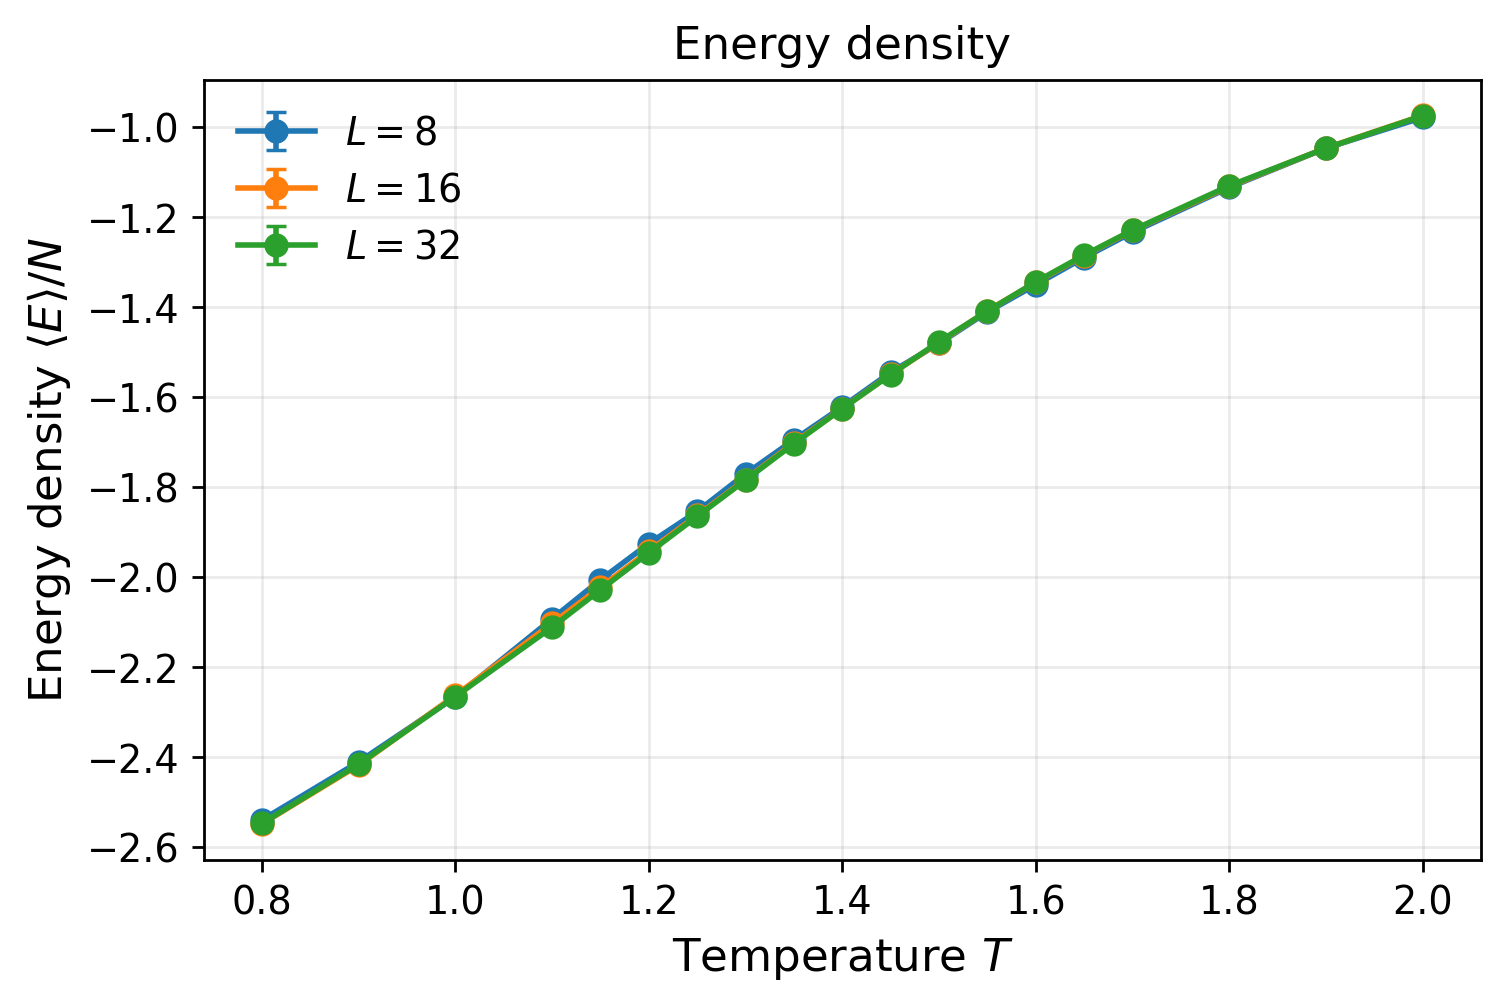

## Physics: heat capacity

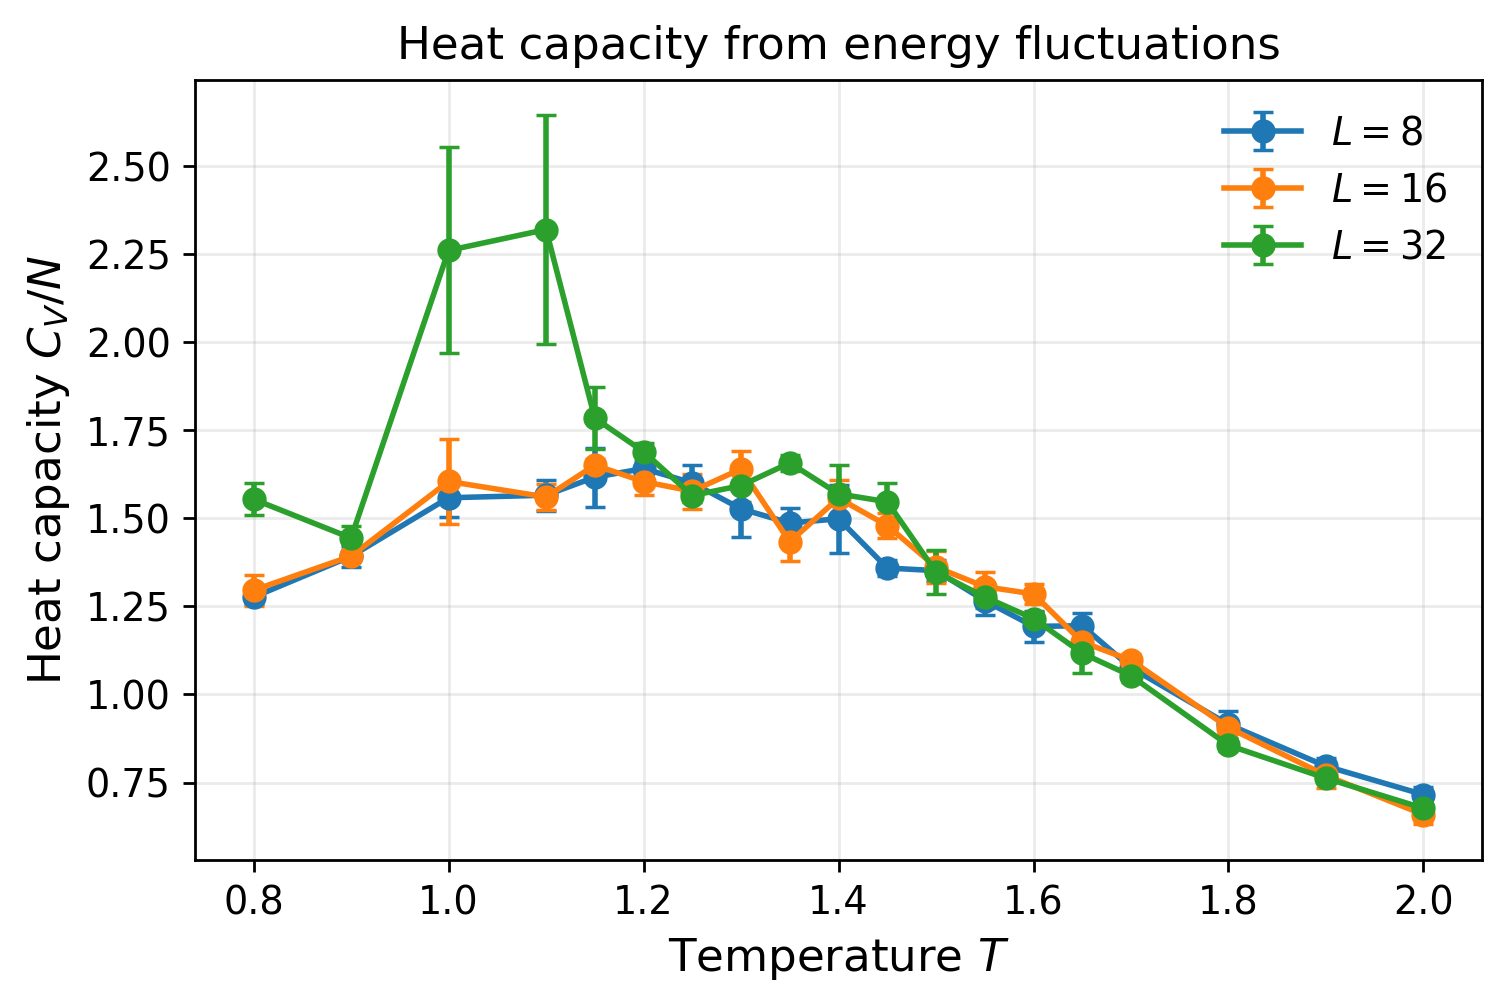

## Physics: helical order

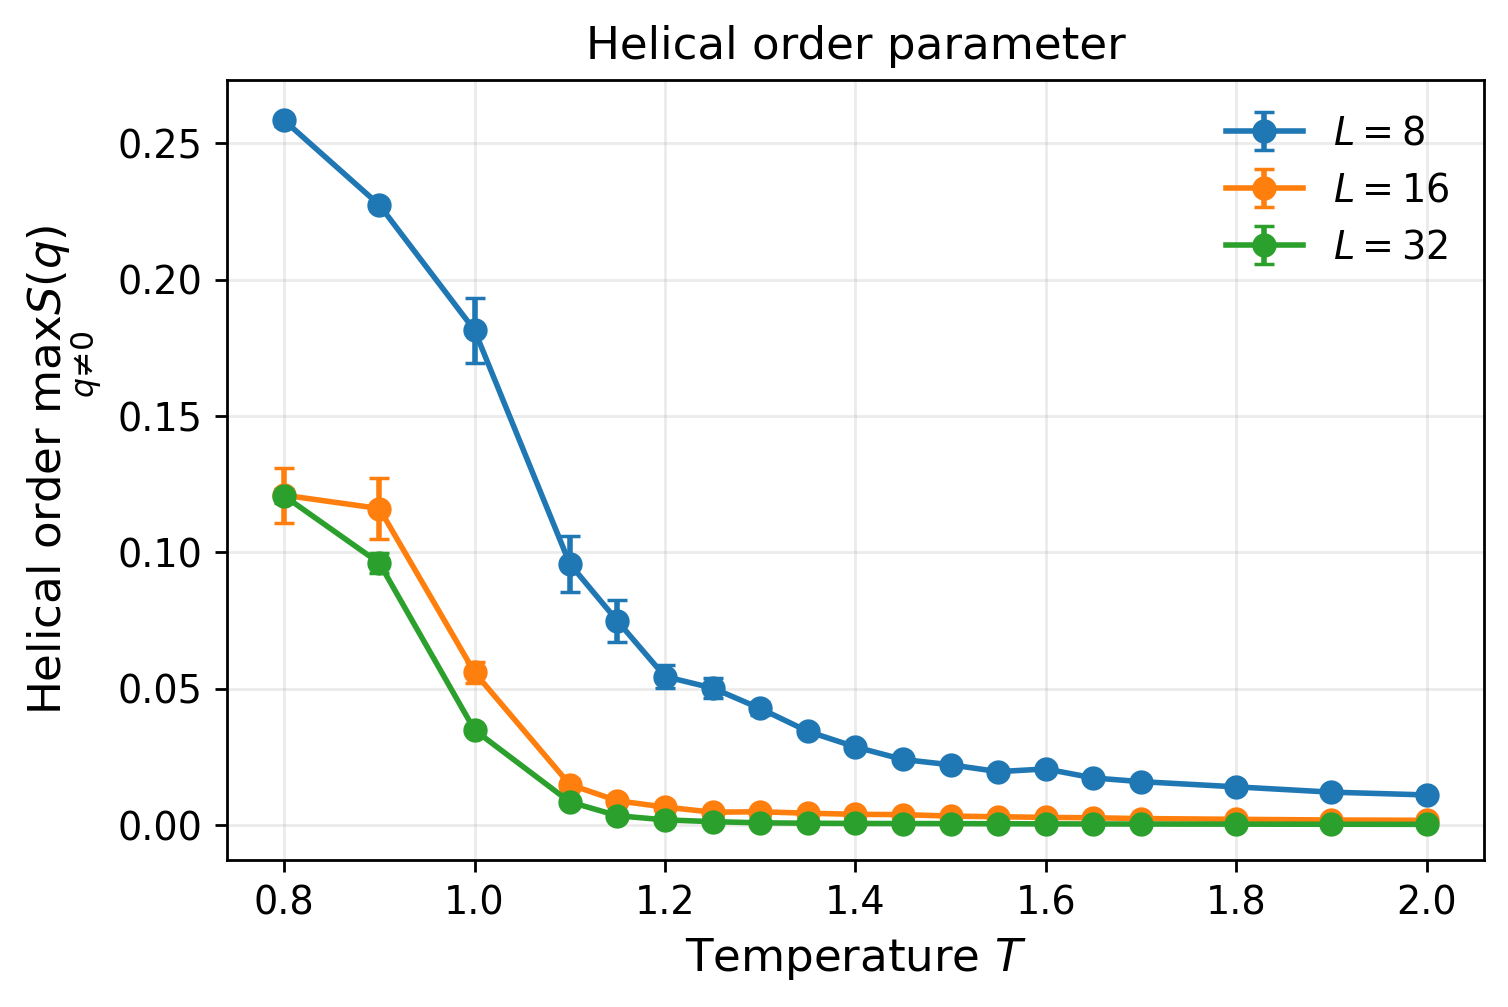

## Physics: dominant wavevector

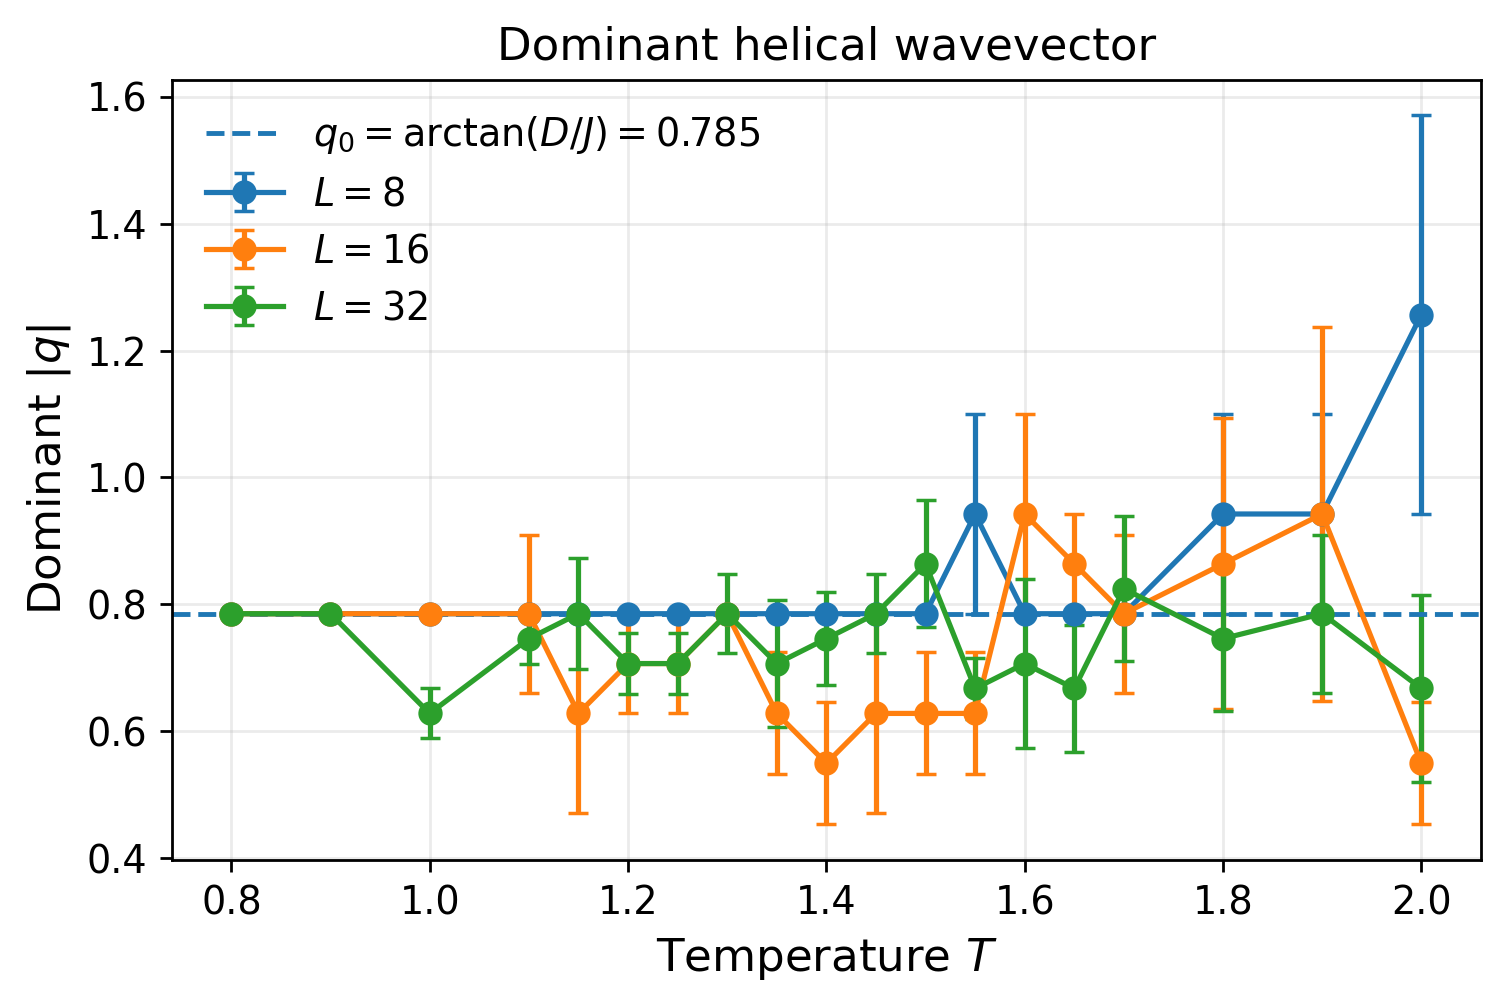

## ML vs physics transition

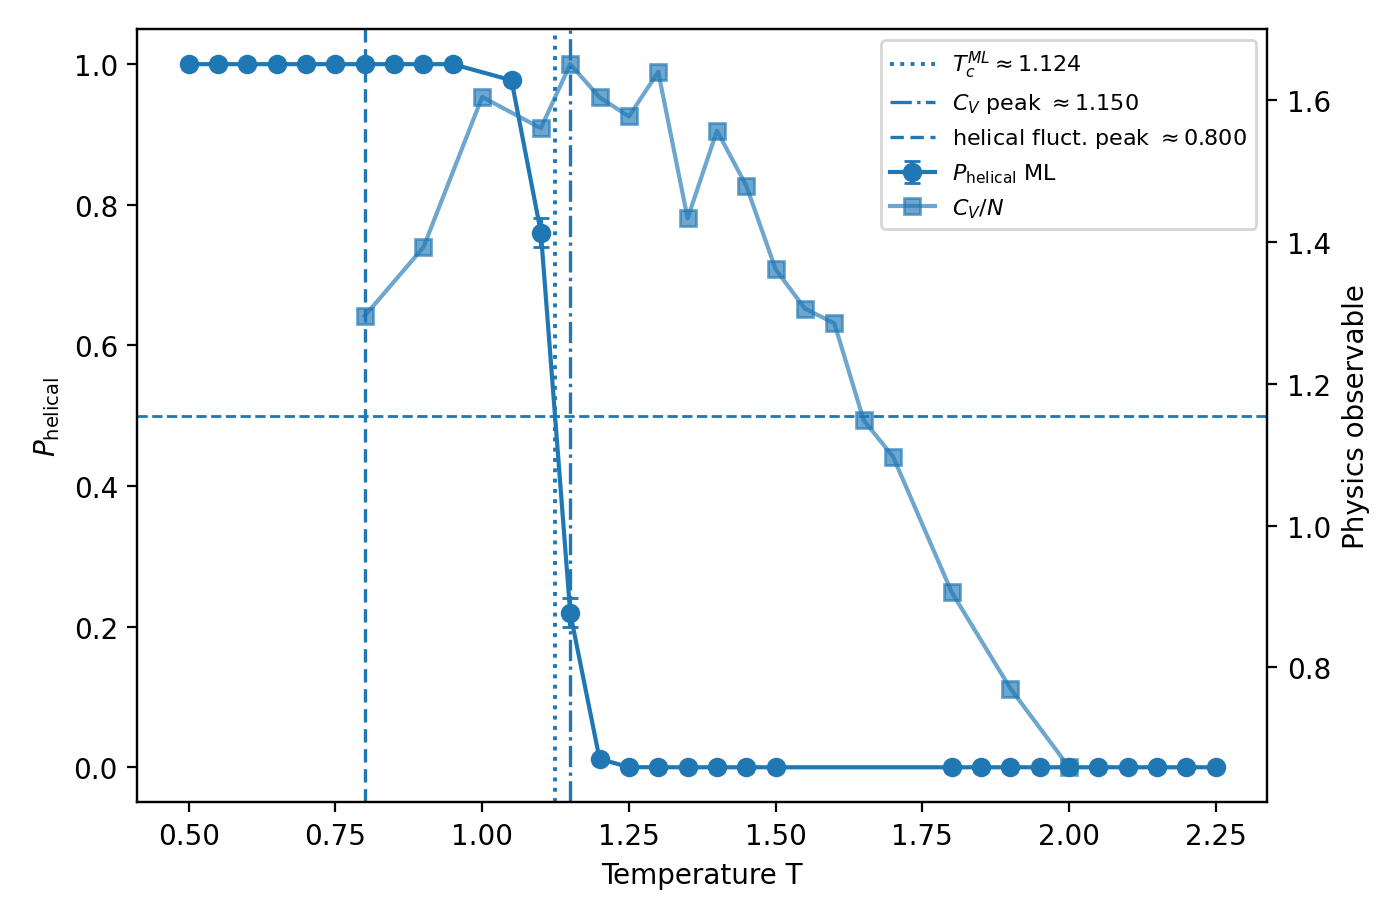

## Feature baseline

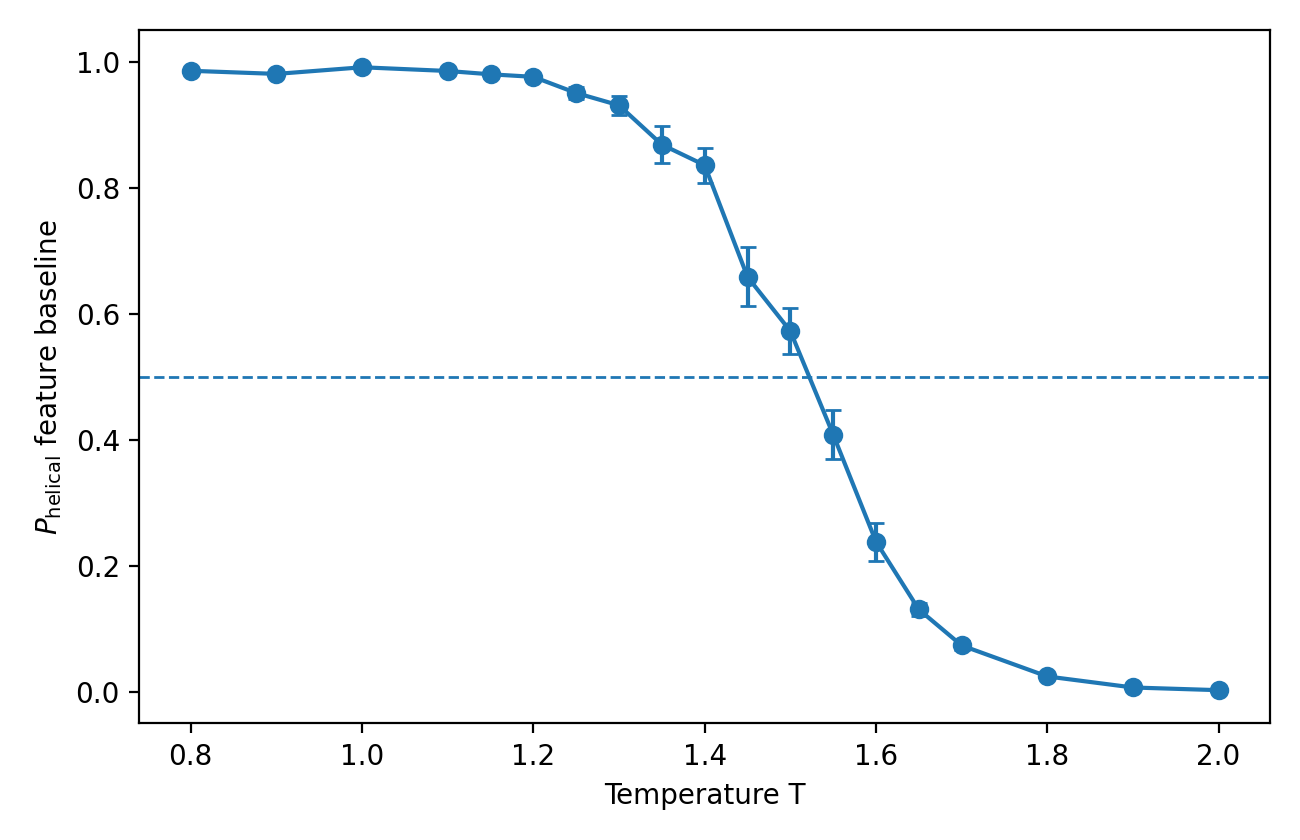

## Structure-factor model

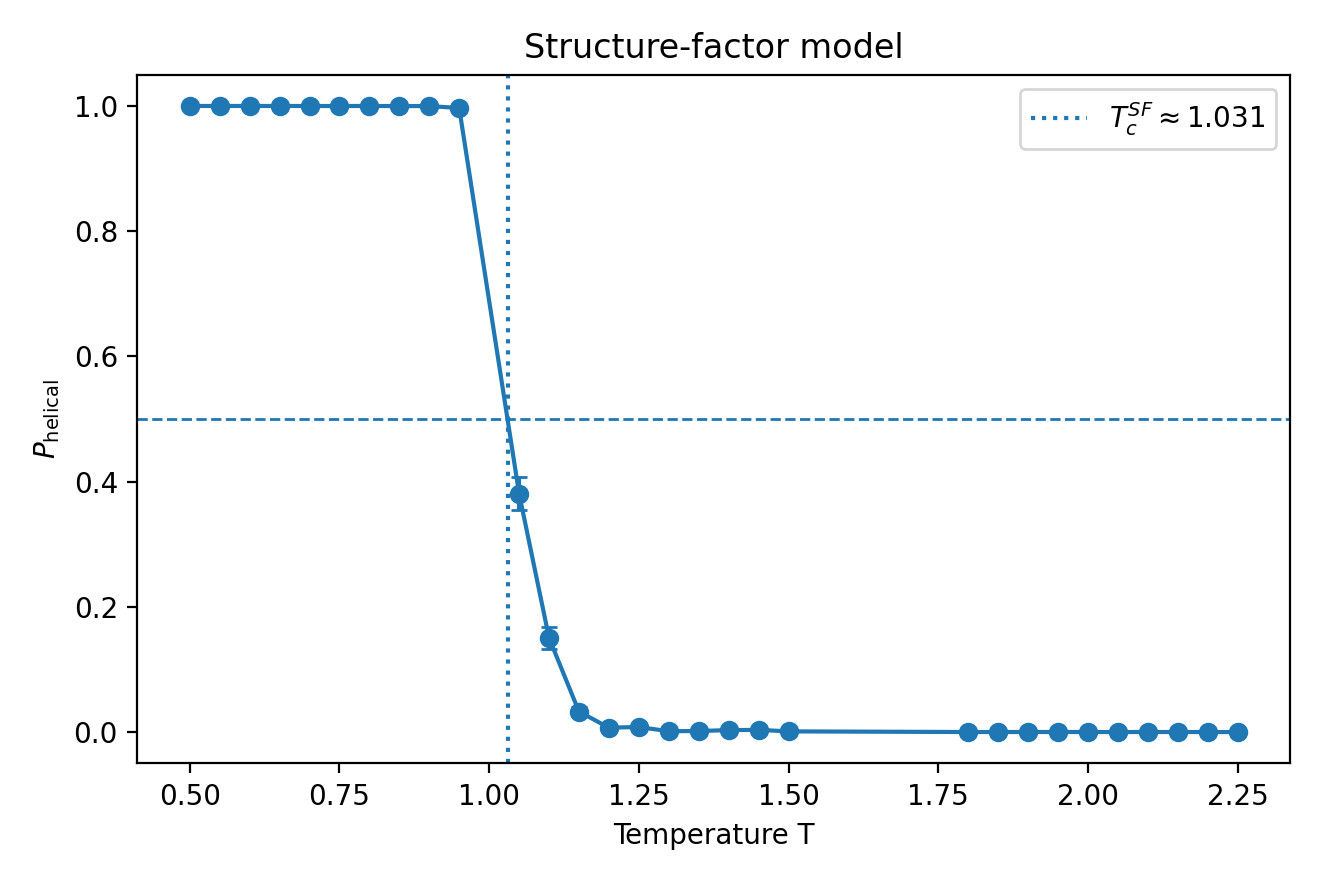

## 3D CNN: P_helical(T)

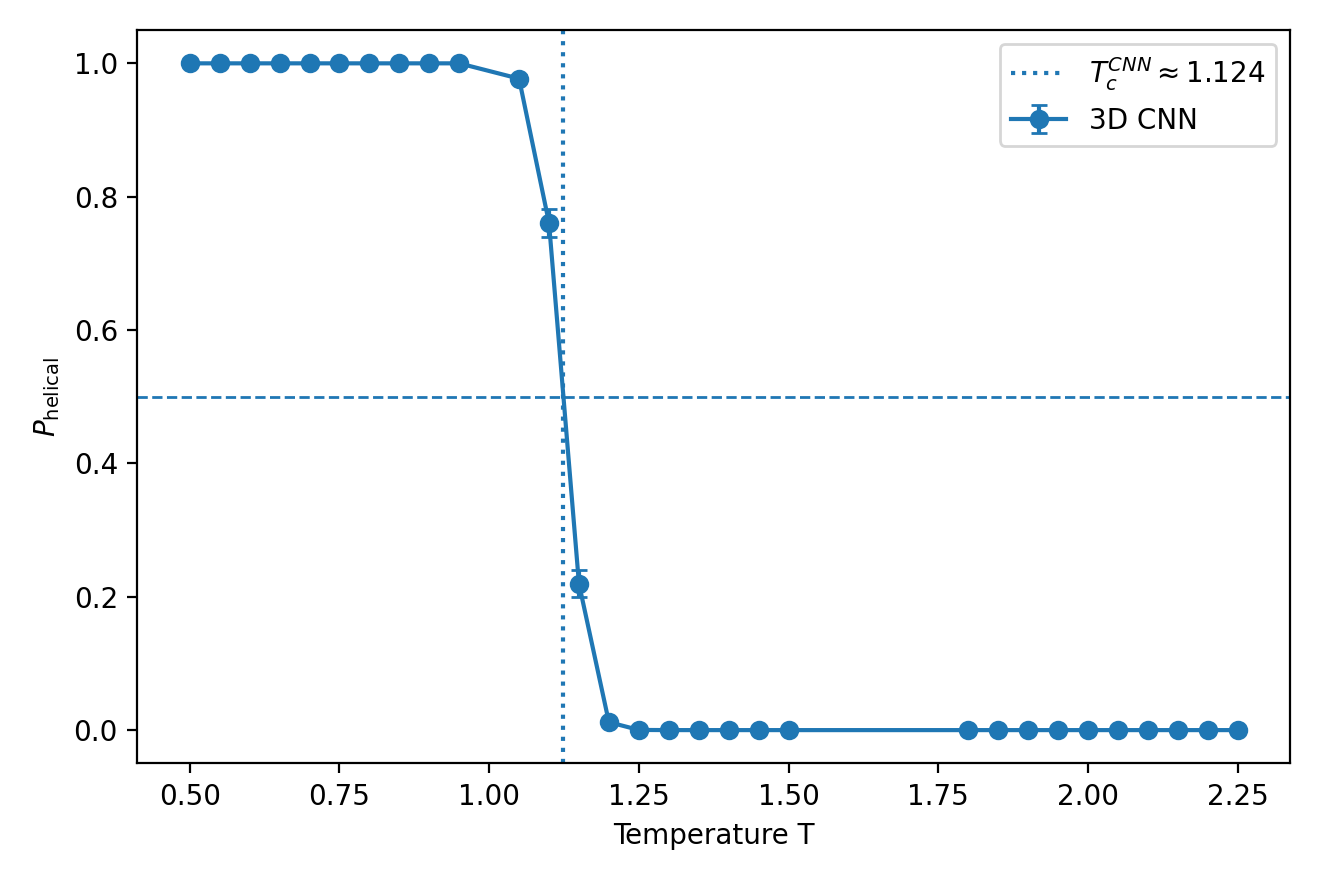

## 3D CNN: loss curve

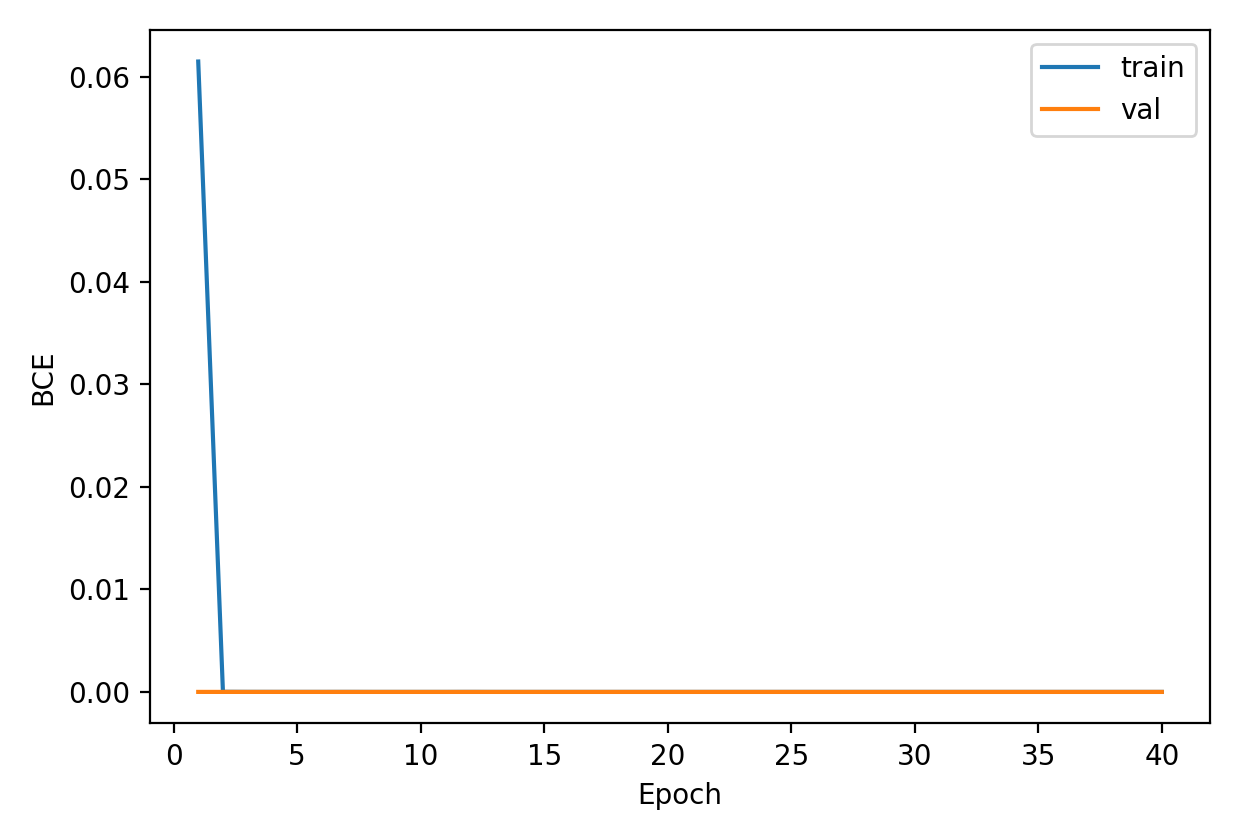

## 3D CNN: accuracy curve

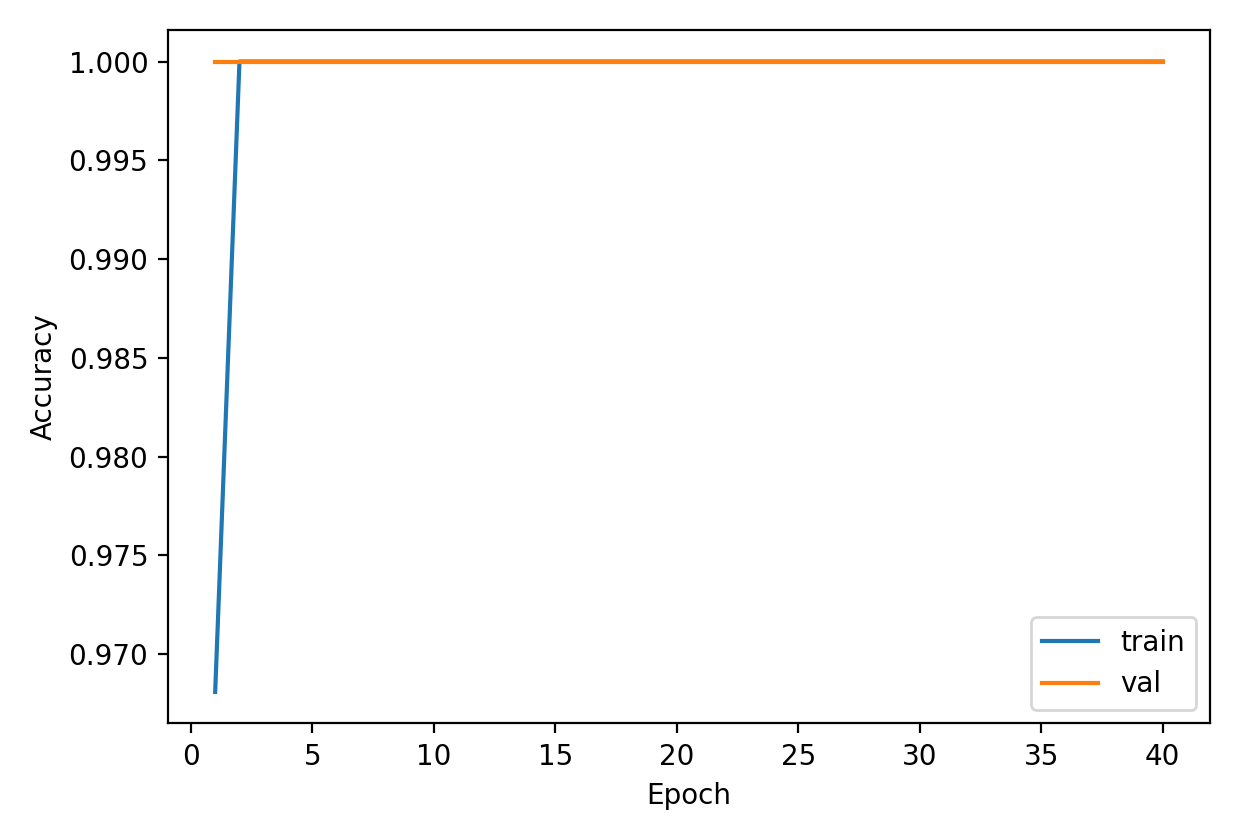

In [39]:
from pathlib import Path
from IPython.display import display, Image, Markdown, FileLink

FIG = Path("/home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report")

display(Markdown(f"Using figure folder: `{FIG}`"))
display(Markdown(f"Exists: `{FIG.exists()}`"))

print("Files in figures/report:")
for f in sorted(FIG.glob("*")):
    print(f.name)

def show_plot(title, names):
    display(Markdown(f"## {title}"))

    for name in names:
        path = FIG / name
        if path.exists():
            if path.suffix.lower() in [".png", ".jpg", ".jpeg"]:
                display(Image(filename=str(path)))
            elif path.suffix.lower() == ".pdf":
                display(FileLink(str(path)))
            else:
                display(Markdown(f"Found: `{path}`"))
            return

    display(Markdown(
        "Missing. Tried:\n" + "\n".join([f"- `{FIG / name}`" for name in names])
    ))

plots = [
    (
        "Physics: energy density",
        [
            "energy_density_vs_T_report.png",
            "energy_density_vs_T_report.pdf",
            "energy_vs_T.png",
            "energy_vs_T.pdf",
        ],
    ),
    (
        "Physics: heat capacity",
        [
            "heat_capacity_vs_T_report.png",
            "heat_capacity_vs_T_report.pdf",
            "heat_capacity_vs_T.png",
            "heat_capacity_vs_T.pdf",
        ],
    ),
    (
        "Physics: helical order",
        [
            "helical_order_vs_T_report.png",
            "helical_order_vs_T_report.pdf",
            "helical_order_vs_T.png",
            "helical_order_vs_T.pdf",
        ],
    ),
    (
        "Physics: dominant wavevector",
        [
            "dominant_q_vs_T_report.png",
            "dominant_q_vs_T_report.pdf",
        ],
    ),
    (
        "ML vs physics transition",
        [
            "ml_vs_physics_transition.png",
            "ml_vs_physics_transition.pdf",
        ],
    ),
    (
        "Feature baseline",
        [
            "feature_baseline_P_helical_vs_T.png",
            "feature_baseline_P_helical_vs_T.pdf",
        ],
    ),
    (
        "Structure-factor model",
        [
            "structure_factor_P_helical_vs_T_ml_data_sf_L16.png",
            "structure_factor_P_helical_vs_T_ml_data_sf_L16.pdf",
            "structure_factor_P_helical_vs_T.png",
            "structure_factor_P_helical_vs_T.pdf",
        ],
    ),
    (
        "3D CNN: P_helical(T)",
        [
            "cnn3d_P_helical_vs_T_ml_data_L16.png",
            "cnn3d_P_helical_vs_T_ml_data_L16.pdf",
            "cnn3d_P_helical_vs_T.png",
            "cnn3d_P_helical_vs_T.pdf",
        ],
    ),
    (
        "3D CNN: loss curve",
        [
            "cnn3d_loss_curve_ml_data_L16.png",
            "cnn3d_loss_curve_ml_data_L16.pdf",
        ],
    ),
    (
        "3D CNN: accuracy curve",
        [
            "cnn3d_accuracy_curve_ml_data_L16.png",
            "cnn3d_accuracy_curve_ml_data_L16.pdf",
        ],
    ),
]

for title, names in plots:
    show_plot(title, names)

# VISUALIZATION FOR L = 32 

Project root: `/home/iason/projects/CSP26/Computational_Statistical_Physics/Project`

Config folder: `/home/iason/projects/CSP26/Computational_Statistical_Physics/Project/results/configs`

Found 8 L=32 configs:
  config_L32_T0p600_J1p000_D1p000_seed701.csv
  config_L32_T0p800_J1p000_D1p000_seed702.csv
  config_L32_T1p000_J1p000_D1p000_seed703.csv
  config_L32_T1p100_J1p000_D1p000_seed704.csv
  config_L32_T1p150_J1p000_D1p000_seed705.csv
  config_L32_T1p250_J1p000_D1p000_seed706.csv
  config_L32_T1p500_J1p000_D1p000_seed707.csv
  config_L32_T2p100_J1p000_D1p000_seed708.csv


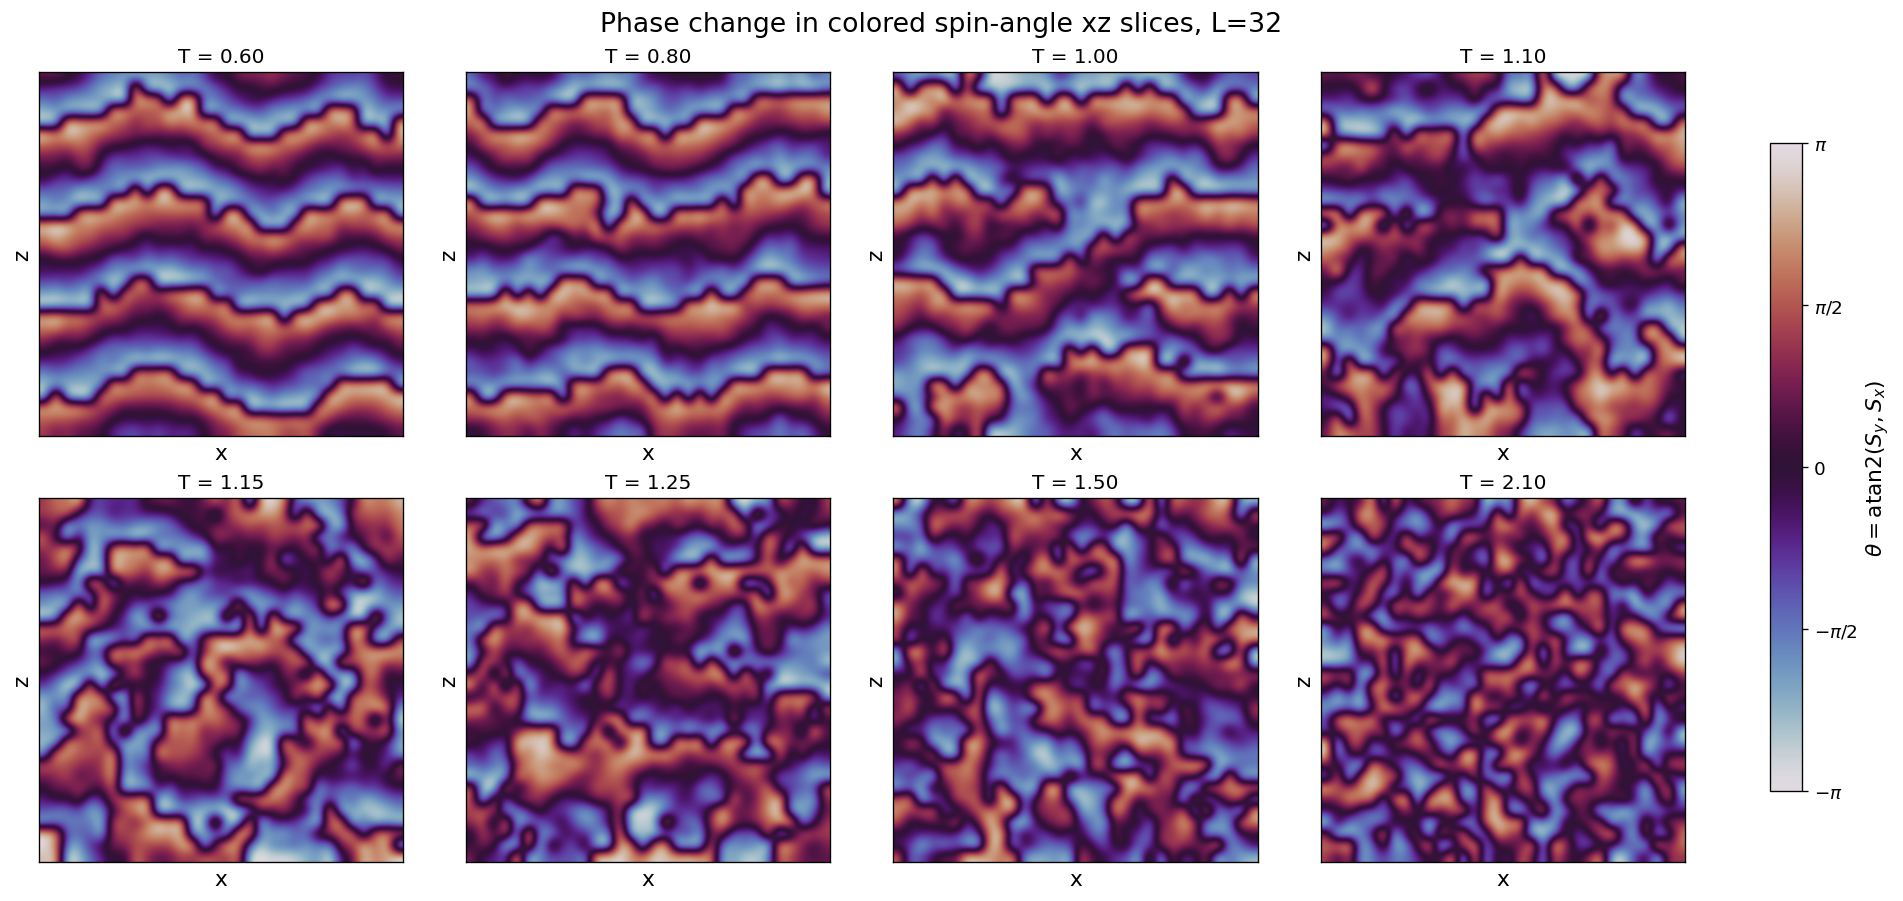

Saved PNG: `/home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/phase_change_colored_slices_L32_notebook.png`

Saved PDF: `/home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/phase_change_colored_slices_L32_notebook.pdf`

In [40]:
from pathlib import Path
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

# ------------------------------------------------------------
# Robust project-root detection
# ------------------------------------------------------------
cwd = Path.cwd()
if (cwd / "results").exists():
    ROOT = cwd
elif (cwd.parent / "results").exists():
    ROOT = cwd.parent
else:
    ROOT = Path("/home/iason/projects/CSP26/Computational_Statistical_Physics/Project")

CONFIG_DIR = ROOT / "results" / "configs"
OUT_DIR = ROOT / "figures" / "report"
OUT_DIR.mkdir(parents=True, exist_ok=True)

display(Markdown(f"Project root: `{ROOT}`"))
display(Markdown(f"Config folder: `{CONFIG_DIR}`"))

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def parse_temperature(path: Path):
    m = re.search(r"_T([0-9]+)p([0-9]+)_", path.name)
    if m is None:
        return None
    return float(m.group(1) + "." + m.group(2))

def load_config_csv(path: Path):
    df = pd.read_csv(path)
    L = int(df[["x", "y", "z"]].to_numpy().max()) + 1
    spins = np.zeros((L, L, L, 3), dtype=float)

    for row in df.itertuples(index=False):
        spins[int(row.x), int(row.y), int(row.z), :] = [row.Sx, row.Sy, row.Sz]

    return spins

def normalize(v, eps=1e-12):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return v / np.maximum(n, eps)

def get_spin_slice(spins, plane="xz", index=None, slab_radius=1):
    """
    Extract a 2D slice.
    slab_radius=1 means average over 3 neighboring slices.
    """
    L = spins.shape[0]
    if index is None:
        index = L // 2

    inds = [(index + k) % L for k in range(-slab_radius, slab_radius + 1)]

    if plane == "xz":
        sl = spins[:, inds, :, :].mean(axis=1)
        xlabel, ylabel = "x", "z"
    elif plane == "xy":
        sl = spins[:, :, inds, :].mean(axis=2)
        xlabel, ylabel = "x", "y"
    elif plane == "yz":
        sl = spins[inds, :, :, :].mean(axis=0)
        xlabel, ylabel = "y", "z"
    else:
        raise ValueError("plane must be 'xy', 'xz', or 'yz'")

    sl = normalize(sl)

    # horizontal axis = first coordinate, vertical axis = second coordinate
    sl = np.swapaxes(sl, 0, 1)
    sl = sl[::-1, :, :]

    return sl, xlabel, ylabel

def theta_map(spin_slice):
    return np.arctan2(spin_slice[..., 1], spin_slice[..., 0])

# ------------------------------------------------------------
# Load all L=32 configs and plot phase change
# ------------------------------------------------------------
files = sorted(
    CONFIG_DIR.glob("config_L32_T*_J1p000_D1p000_seed*.csv"),
    key=lambda p: parse_temperature(p) if parse_temperature(p) is not None else 999.0,
)

print(f"Found {len(files)} L=32 configs:")
for f in files:
    print(" ", f.name)

if len(files) == 0:
    raise FileNotFoundError(f"No L=32 configs found in {CONFIG_DIR}")

n = len(files)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4.0 * ncols, 3.7 * nrows),
    constrained_layout=True,
)

axes = np.array(axes).reshape(-1)

im = None
for ax, path in zip(axes, files):
    T = parse_temperature(path)
    spins = load_config_csv(path)
    sl, xlabel, ylabel = get_spin_slice(spins, plane="xz", slab_radius=1)
    theta = theta_map(sl)

    im = ax.imshow(
        theta,
        cmap="twilight",
        vmin=-np.pi,
        vmax=np.pi,
        interpolation="bicubic",
    )

    ax.set_title(f"T = {T:.2f}", fontsize=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes[len(files):]:
    ax.axis("off")

cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.82)
cbar.set_label(r"$\theta=\mathrm{atan2}(S_y,S_x)$")
cbar.set_ticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
cbar.set_ticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])

fig.suptitle(
    "Phase change in colored spin-angle xz slices, L=32",
    fontsize=16,
)

out_png = OUT_DIR / "phase_change_colored_slices_L32_notebook.png"
out_pdf = OUT_DIR / "phase_change_colored_slices_L32_notebook.pdf"

fig.savefig(out_png, dpi=450, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")

plt.show()

display(Markdown(f"Saved PNG: `{out_png}`"))
display(Markdown(f"Saved PDF: `{out_pdf}`"))

Using config folder: `/home/iason/projects/CSP26/Computational_Statistical_Physics/Project/results/configs`

Saving to: `/home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/visual_options`

Low-T file:  config_L32_T0p600_J1p000_D1p000_seed701.csv T = 0.6
High-T file: config_L32_T2p100_J1p000_D1p000_seed708.csv T = 2.1


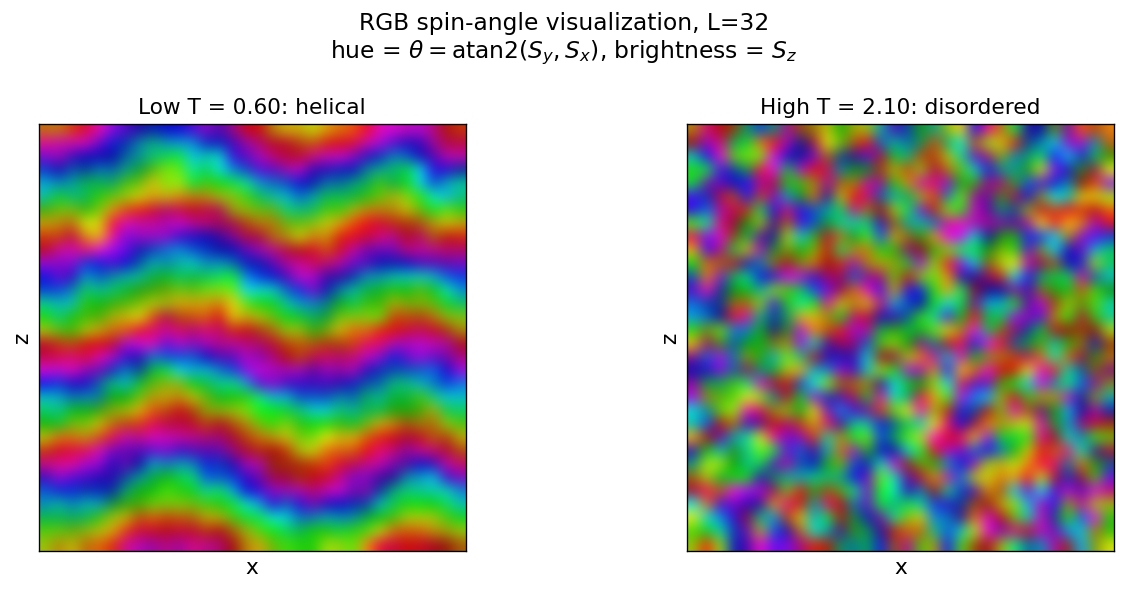

Saved PNG: `/home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/visual_options/03_rgb_bicubic_slab_average_3_slices_L32.png`

Saved PDF: `/home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/visual_options/03_rgb_bicubic_slab_average_3_slices_L32.pdf`

In [41]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from IPython.display import display, Markdown, Image

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
cwd = Path.cwd()
if (cwd / "results").exists():
    ROOT = cwd
elif (cwd.parent / "results").exists():
    ROOT = cwd.parent
else:
    ROOT = Path("/home/iason/projects/CSP26/Computational_Statistical_Physics/Project")

CONFIG_DIR = ROOT / "results" / "configs"
OUTDIR = ROOT / "figures" / "report" / "visual_options"
OUTDIR.mkdir(parents=True, exist_ok=True)

display(Markdown(f"Using config folder: `{CONFIG_DIR}`"))
display(Markdown(f"Saving to: `{OUTDIR}`"))

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def parse_temperature(path: Path):
    m = re.search(r"_T([0-9]+)p([0-9]+)_", path.name)
    if m is None:
        return None
    return float(m.group(1) + "." + m.group(2))

def load_config_csv(path: Path):
    df = pd.read_csv(path)
    L = int(df[["x", "y", "z"]].to_numpy().max()) + 1
    spins = np.zeros((L, L, L, 3), dtype=float)

    for row in df.itertuples(index=False):
        spins[int(row.x), int(row.y), int(row.z), :] = [row.Sx, row.Sy, row.Sz]

    return spins

def normalize(v, eps=1e-12):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return v / np.maximum(n, eps)

def get_spin_slice(spins, plane="xz", index=None, slab_radius=1):
    L = spins.shape[0]
    if index is None:
        index = L // 2

    inds = [(index + k) % L for k in range(-slab_radius, slab_radius + 1)]

    if plane == "xz":
        sl = spins[:, inds, :, :].mean(axis=1)
        xlabel, ylabel = "x", "z"
    elif plane == "xy":
        sl = spins[:, :, inds, :].mean(axis=2)
        xlabel, ylabel = "x", "y"
    elif plane == "yz":
        sl = spins[inds, :, :, :].mean(axis=0)
        xlabel, ylabel = "y", "z"
    else:
        raise ValueError("plane must be 'xy', 'xz', or 'yz'")

    sl = normalize(sl)
    sl = np.swapaxes(sl, 0, 1)
    sl = sl[::-1, :, :]

    return sl, xlabel, ylabel

def rgb_from_spin_slice(sl, use_sz_brightness=True):
    """
    Hue = atan2(Sy,Sx), brightness optionally encodes Sz.
    """
    sx = sl[..., 0]
    sy = sl[..., 1]
    sz = sl[..., 2]

    theta = np.arctan2(sy, sx)
    hue = (theta / (2 * np.pi)) % 1.0
    saturation = np.ones_like(hue) * 0.95

    if use_sz_brightness:
        value = 0.55 + 0.45 * (sz + 1.0) / 2.0
    else:
        value = np.ones_like(hue)

    hsv = np.stack([hue, saturation, value], axis=-1)
    return hsv_to_rgb(hsv)

# ------------------------------------------------------------
# Pick low-T and high-T L=32 configs automatically
# ------------------------------------------------------------
files = sorted(
    CONFIG_DIR.glob("config_L32_T*_J1p000_D1p000_seed*.csv"),
    key=lambda p: parse_temperature(p) if parse_temperature(p) is not None else 999.0,
)

if len(files) == 0:
    raise FileNotFoundError(f"No L=32 configs found in {CONFIG_DIR}")

low_file = files[0]
high_file = files[-1]

low_T = parse_temperature(low_file)
high_T = parse_temperature(high_file)

print("Low-T file: ", low_file.name, "T =", low_T)
print("High-T file:", high_file.name, "T =", high_T)

low_spins = load_config_csv(low_file)
high_spins = load_config_csv(high_file)

# ------------------------------------------------------------
# Option 03: RGB + bicubic + slab average over 3 slices
# ------------------------------------------------------------
low_sl, xlabel, ylabel = get_spin_slice(
    low_spins,
    plane="xz",
    slab_radius=1,   # average over 3 slices
)
high_sl, _, _ = get_spin_slice(
    high_spins,
    plane="xz",
    slab_radius=1,
)

low_img = rgb_from_spin_slice(low_sl, use_sz_brightness=True)
high_img = rgb_from_spin_slice(high_sl, use_sz_brightness=True)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 5.0))

axes[0].imshow(low_img, interpolation="bicubic")
axes[0].set_title(f"Low T = {low_T:.2f}: helical")
axes[0].set_xlabel(xlabel)
axes[0].set_ylabel(ylabel)

axes[1].imshow(high_img, interpolation="bicubic")
axes[1].set_title(f"High T = {high_T:.2f}: disordered")
axes[1].set_xlabel(xlabel)
axes[1].set_ylabel(ylabel)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    "RGB spin-angle visualization, L=32\n"
    r"hue = $\theta=\mathrm{atan2}(S_y,S_x)$, brightness = $S_z$",
    fontsize=14,
)

fig.tight_layout()

out_png = OUTDIR / "03_rgb_bicubic_slab_average_3_slices_L32.png"
out_pdf = OUTDIR / "03_rgb_bicubic_slab_average_3_slices_L32.pdf"

fig.savefig(out_png, dpi=450, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")

plt.show()

display(Markdown(f"Saved PNG: `{out_png}`"))
display(Markdown(f"Saved PDF: `{out_pdf}`"))

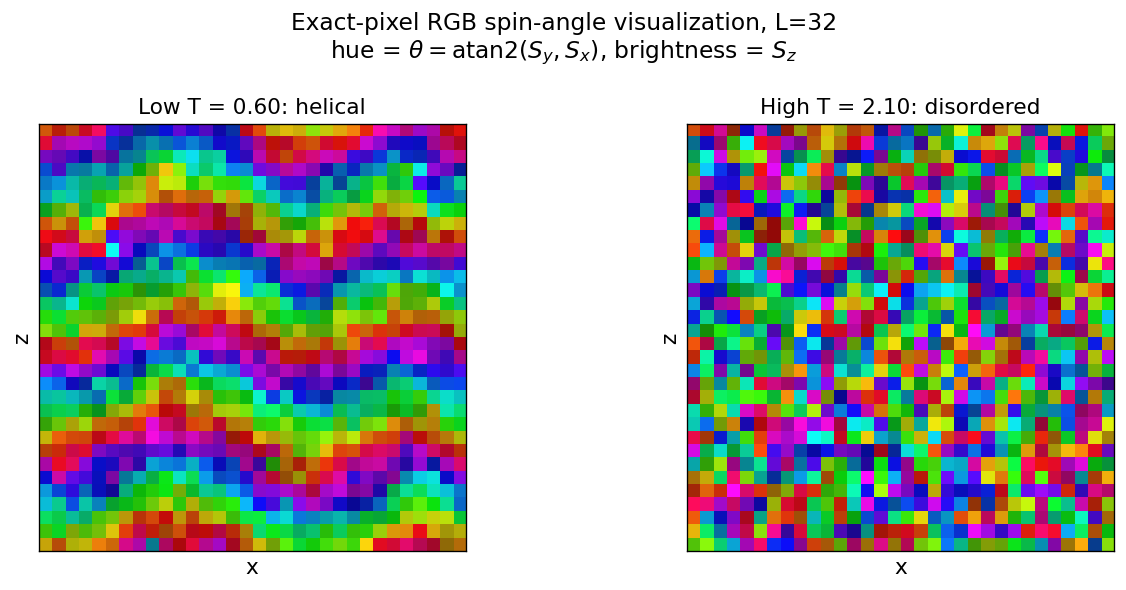

Saved PNG: `/home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/visual_options/03b_rgb_exact_pixels_no_blur_L32.png`

Saved PDF: `/home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/visual_options/03b_rgb_exact_pixels_no_blur_L32.pdf`

In [42]:
# ============================================================
# Crisp / non-blurry L=32 visualization
# Exact lattice pixels, no slab averaging, no bicubic smoothing
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

OUTDIR = ROOT / "figures" / "report" / "visual_options"
OUTDIR.mkdir(parents=True, exist_ok=True)

# Reload low/high configs
low_spins = load_config_csv(low_file)
high_spins = load_config_csv(high_file)

# No slab averaging: exact xz slice
low_sl, xlabel, ylabel = get_spin_slice(
    low_spins,
    plane="xz",
    slab_radius=0,
)

high_sl, _, _ = get_spin_slice(
    high_spins,
    plane="xz",
    slab_radius=0,
)

low_img = rgb_from_spin_slice(low_sl, use_sz_brightness=True)
high_img = rgb_from_spin_slice(high_sl, use_sz_brightness=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].imshow(low_img, interpolation="nearest")
axes[0].set_title(f"Low T = {low_T:.2f}: helical")
axes[0].set_xlabel(xlabel)
axes[0].set_ylabel(ylabel)

axes[1].imshow(high_img, interpolation="nearest")
axes[1].set_title(f"High T = {high_T:.2f}: disordered")
axes[1].set_xlabel(xlabel)
axes[1].set_ylabel(ylabel)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    "Exact-pixel RGB spin-angle visualization, L=32\n"
    r"hue = $\theta=\mathrm{atan2}(S_y,S_x)$, brightness = $S_z$",
    fontsize=14,
)

fig.tight_layout()

out_png = OUTDIR / "03b_rgb_exact_pixels_no_blur_L32.png"
out_pdf = OUTDIR / "03b_rgb_exact_pixels_no_blur_L32.pdf"

fig.savefig(out_png, dpi=450, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")

plt.show()

display(Markdown(f"Saved PNG: `{out_png}`"))
display(Markdown(f"Saved PDF: `{out_pdf}`"))

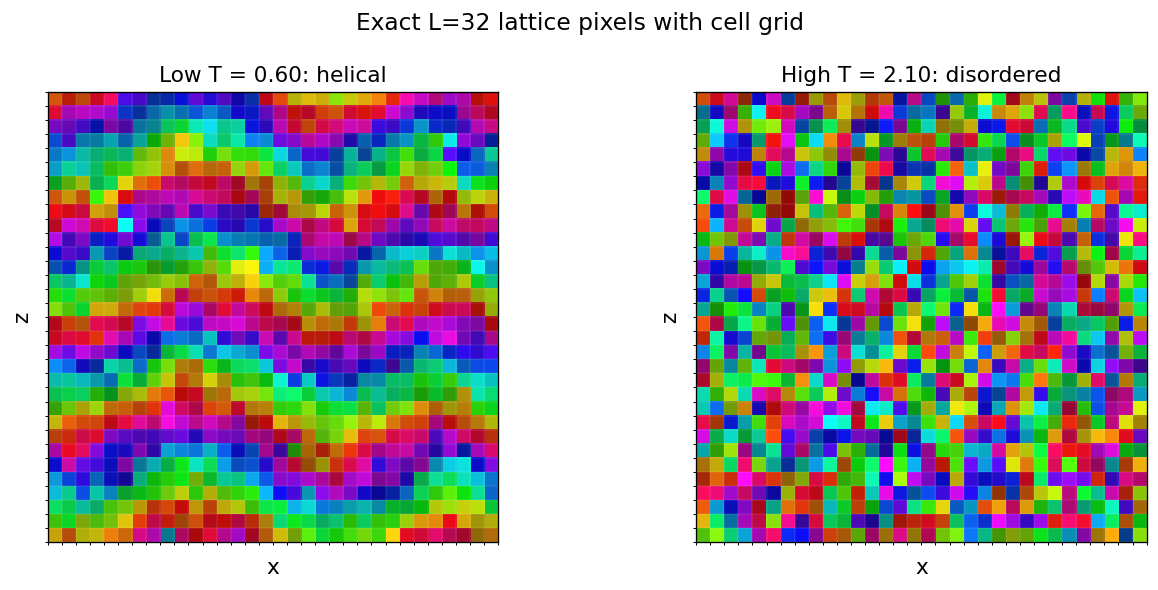

Saved PNG: `/home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/visual_options/03c_rgb_exact_pixels_with_grid_L32.png`

Saved PDF: `/home/iason/projects/CSP26/Computational_Statistical_Physics/Project/figures/report/visual_options/03c_rgb_exact_pixels_with_grid_L32.pdf`

In [43]:
# ============================================================
# Same plot, but with visible lattice cells / grid
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, img, title in [
    (axes[0], low_img, f"Low T = {low_T:.2f}: helical"),
    (axes[1], high_img, f"High T = {high_T:.2f}: disordered"),
]:
    ax.imshow(img, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks(np.arange(-0.5, img.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, img.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.25, alpha=0.35)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("x")
    ax.set_ylabel("z")

fig.suptitle("Exact L=32 lattice pixels with cell grid", fontsize=14)
fig.tight_layout()

out_png = OUTDIR / "03c_rgb_exact_pixels_with_grid_L32.png"
out_pdf = OUTDIR / "03c_rgb_exact_pixels_with_grid_L32.pdf"

fig.savefig(out_png, dpi=450, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")

plt.show()

display(Markdown(f"Saved PNG: `{out_png}`"))
display(Markdown(f"Saved PDF: `{out_pdf}`"))